# FCHS-Set Pipeline — Music Streaming Application
### Fuzzy Contextual Hypersoft Set: User Listening Profile & Recommendation

**Structure**
- **Universe U** — listeners (users)
- **Context C₁ × C₂** — Time Slot × Season (24 combinations)
- **Attributes A₁–A₇** — Tempo · Energy · Valence · Acousticness · Danceability · Vocal Presence · Popularity

**Pipeline steps**
1. Install & import libraries
2. Upload data files
3. Load & filter listening history
4. Load & prepare audio features
5. Join listening history with audio features
6. Derive context columns (C₁, C₂)
7. Bin audio features into attribute categories (A₁–A₇)
8. Compute fuzzy memberships μ(u,c)(a)
9. Build dominant profile table
10. Compute product recommendation scores
11. Generate top-3 recommendations
12. Export results to CSV


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Install & import libraries
Run this first. It installs any missing packages and imports everything needed.

In [ ]:
# Install required packages (safe to run even if already installed)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pandas", "numpy", "scikit-learn", "matplotlib",
                "seaborn", "rapidfuzz", "tqdm", "--quiet"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz
from tqdm import tqdm
from datetime import date, timedelta
import warnings, os, re
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("✓ All libraries loaded successfully")


✓ All libraries loaded successfully


## Cell 2 — Upload your data files

You need two files. Upload both using the file upload button in Google Colab
(the folder icon on the left sidebar → upload icon).

**File 1 — Last.fm 1K listening history**
- Download from: http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html
- File to upload: `userid-timestamp-artid-artname-traid-traname.tsv`

**File 2 — Spotify audio features**
- Download from Kaggle: https://www.kaggle.com/datasets/maharshipandya/spotify-tracks-dataset
- File to upload: `dataset.csv`

Once both files are uploaded, run this cell to confirm they are found.


In [ ]:
import os

LASTFM_FILE = '/content/drive/MyDrive/userid-timestamp-artid-artname-traid-traname.tsv'
SPOTIFY_FILE = '/content/drive/MyDrive/dataset.csv'

for fpath in [LASTFM_FILE, SPOTIFY_FILE]:
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"Found: {os.path.basename(fpath)} ({size_mb:.1f} MB)")
    else:
        print(f"NOT FOUND: {fpath}")

Found: userid-timestamp-artid-artname-traid-traname.tsv (2412.0 MB)
Found: dataset.csv (19.2 MB)


## Cell 3 — Load & filter listening history

Reads the Last.fm 1K file. Keeps only users with at least 500 listening events
so that membership values are statistically meaningful.
You can adjust `MIN_LISTENS` if you want more or fewer users.


In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
MIN_LISTENS   = 500    # minimum listens per user
MAX_USERS     = 30     # maximum number of users to keep

# ── Load raw file ─────────────────────────────────────────────────────────────
print("Loading Last.fm listening history...")
lastfm_raw = pd.read_csv(
    LASTFM_FILE,
    sep="\t",
    header=None,
    names=["user_id", "timestamp", "artist_id", "artists",
           "track_id", "track_name"],
    encoding="utf-8",
    on_bad_lines="skip"
)
print(f"  Raw rows loaded: {len(lastfm_raw):,}")

# ── Parse timestamps ──────────────────────────────────────────────────────────
lastfm_raw["timestamp"] = pd.to_datetime(
    lastfm_raw["timestamp"], utc=True, errors="coerce"
)
lastfm_raw = lastfm_raw.dropna(subset=["timestamp", "track_name", "artists"])
print(f"  Rows after dropping bad timestamps: {len(lastfm_raw):,}")

# ── Filter users ──────────────────────────────────────────────────────────────
user_counts = lastfm_raw["user_id"].value_counts()
eligible    = user_counts[user_counts >= MIN_LISTENS].head(MAX_USERS).index
lastfm      = lastfm_raw[lastfm_raw["user_id"].isin(eligible)].copy()
lastfm      = lastfm.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

print(f"\n✓ Filtered dataset")
print(f"  Users kept : {lastfm['user_id'].nunique()}")
print(f"  Total rows : {len(lastfm):,}")
print(f"  Date range : {lastfm['timestamp'].min().date()} → {lastfm['timestamp'].max().date()}")
print(f"\nListens per user:")
print(lastfm["user_id"].value_counts().to_string())


Loading Last.fm listening history...
  Raw rows loaded: 19,098,853
  Rows after dropping bad timestamps: 19,098,643

✓ Filtered dataset
  Users kept : 30
  Total rows : 3,234,923
  Date range : 2005-02-14 → 2009-06-19

Listens per user:
user_id
user_000949    183103
user_000791    158686
user_000544    157859
user_000861    154015
user_000800    141956
user_000691    129327
user_000274    125133
user_000155    122037
user_000233    117488
user_000349    114070
user_000458    113096
user_000427    111734
user_000529    108671
user_000033     96436
user_000451     95879
user_000702     95452
user_000709     93498
user_000298     92369
user_000543     92007
user_000833     91639
user_000054     90931
user_000348     90445
user_000199     90368
user_000793     85215
user_000685     84442
user_000357     81469
user_000612     81042
user_000577     80313
user_000313     78150
user_000774     78093


## Cell 4 — Load & prepare Spotify audio features

Loads the Spotify tracks CSV which contains pre-computed audio features
for ~114,000 tracks. These features were collected before Spotify deprecated
their audio features API in November 2024.


In [ ]:
print("Loading Spotify audio features...")
spotify_raw = pd.read_csv(SPOTIFY_FILE)
print(f"  Rows loaded: {len(spotify_raw):,}")
print(f"  Columns    : {list(spotify_raw.columns)}")

# Keep only needed columns (using actual column names)
needed = ["track_name", "artists", "energy", "valence", "tempo",
          "acousticness", "danceability", "instrumentalness", "popularity", "duration_ms"]

missing = [c for c in needed if c not in spotify_raw.columns]
if missing:
    print(f"  Missing columns: {missing}")
else:
    spotify = spotify_raw[needed].dropna().drop_duplicates(
        subset=["track_name", "artists"]
    ).copy()
    spotify["track_lower"]  = spotify["track_name"].str.lower().str.strip()
    spotify["artist_lower"] = spotify["artists"].str.lower().str.strip()
    print(f"  Tracks after dedup: {len(spotify):,}")
    print("  Spotify data ready")

Loading Spotify audio features...
  Rows loaded: 114,000
  Columns    : ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
  Tracks after dedup: 81,343
  Spotify data ready


## Cell 5 — Join listening history with audio features

Matches each Last.fm listening event to its Spotify audio features using
artist name + track name. Tries exact match first, then fuzzy match for
slight spelling differences. Unmatched rows are dropped.

This cell may take **2–5 minutes** depending on dataset size.


In [ ]:
print("Joining Last.fm with Spotify audio features...")

# Build join keys using correct column names
lastfm["join_key"] = (
    lastfm["artists"].str.lower().str.strip() + " ||| " +
    lastfm["track_name"].str.lower().str.strip()
)

spotify["join_key"] = (
    spotify["artist_lower"] + " ||| " +
    spotify["track_lower"]
)

# Exact match only
spotify_lookup = spotify.set_index("join_key")
matched = lastfm[lastfm["join_key"].isin(spotify_lookup.index)].copy()
matched = matched.join(
    spotify_lookup.drop(columns=["artists", "track_name", "track_lower", "artist_lower"]),
    on="join_key"
)

total = len(lastfm)
n_matched = len(matched)
match_rate = 100 * n_matched / total

print(f"  Matched rows : {n_matched:,}")
print(f"  Match rate   : {match_rate:.1f}%")
print(f"  Unmatched    : {total - n_matched:,}")

events = matched.reset_index(drop=True)
print("  Join complete")

Joining Last.fm with Spotify audio features...
  Matched rows : 206,471
  Match rate   : 6.4%
  Unmatched    : 3,028,452
  Join complete


## Cell 6 — Derive context columns C₁ and C₂

**C₁ — Time slot** (from hour of day)
| Hour | Label |
|------|-------|
| 4–6 | early morning |
| 7–11 | morning |
| 12–16 | afternoon |
| 17–20 | evening |
| 21–23 | night |
| 0–3 | late night |

**C₂ — Season** (from month, Northern Hemisphere based)
| Months | Season |
|--------|--------|
| Dec, Jan, Feb | winter |
| Mar, Apr, May | spring |
| Jun, Jul, Aug | summer |
| Sep, Oct, Nov | monsoon |

> Note: "monsoon" replaces "autumn" to align with the paper's framing.
> For a global dataset this is a naming convention — the underlying
> month grouping is identical to a standard 4-season split.


✓ Context columns derived

C1 — Time slot distribution:
C1
evening          44932
afternoon        44668
late night       34068
night            30729
morning          30670
early morning    21404

C2 — Season distribution:
C2
spring     56114
winter     55681
summer     47413
monsoon    47263


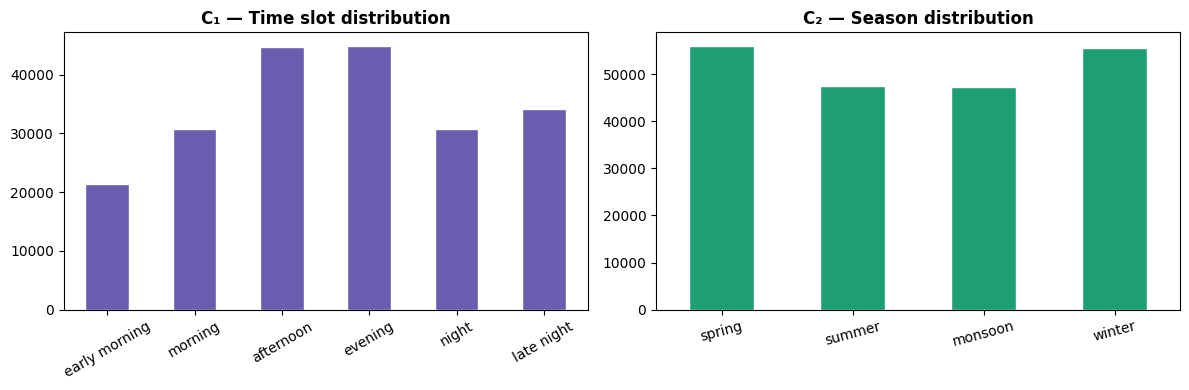


  Chart saved as context_distributions.png


In [ ]:
# ── C1: Time slot ─────────────────────────────────────────────────────────────
def get_time_slot(hour):
    if   4  <= hour <= 6:  return "early morning"
    elif 7  <= hour <= 11: return "morning"
    elif 12 <= hour <= 16: return "afternoon"
    elif 17 <= hour <= 20: return "evening"
    elif 21 <= hour <= 23: return "night"
    else:                  return "late night"   # 0-3

events["hour"]   = events["timestamp"].dt.hour
events["C1"]     = events["hour"].apply(get_time_slot)

# ── C2: Season ────────────────────────────────────────────────────────────────
def get_season(month):
    if   month in [12, 1, 2]:  return "winter"
    elif month in [3, 4, 5]:   return "spring"
    elif month in [6, 7, 8]:   return "summer"
    else:                      return "monsoon"

events["month"]  = events["timestamp"].dt.month
events["C2"]     = events["month"].apply(get_season)

# ── Summary ───────────────────────────────────────────────────────────────────
print("✓ Context columns derived\n")
print("C1 — Time slot distribution:")
print(events["C1"].value_counts().to_string())
print()
print("C2 — Season distribution:")
print(events["C2"].value_counts().to_string())

# ── Plot distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

c1_order = ["early morning","morning","afternoon","evening","night","late night"]
c2_order = ["spring","summer","monsoon","winter"]

events["C1"].value_counts().reindex(c1_order).plot(
    kind="bar", ax=axes[0], color="#6B5CB0", edgecolor="white"
)
axes[0].set_title("C₁ — Time slot distribution", fontweight="bold")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=30)

events["C2"].value_counts().reindex(c2_order).plot(
    kind="bar", ax=axes[1], color="#1D9E75", edgecolor="white"
)
axes[1].set_title("C₂ — Season distribution", fontweight="bold")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("context_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved as context_distributions.png")


## Cell 7 — Bin audio features into attribute categories

Converts continuous Spotify audio feature values (0.0–1.0 floats) into
discrete sub-attribute labels for the FCHS-Set attribute spaces A₁–A₇.

| Attribute | Field | Low | Mid | High |
|-----------|-------|-----|-----|------|
| A₁ Tempo | `tempo` (BPM) | slow <90 | mid 90–140 | fast >140 |
| A₂ Energy | `energy` | low <0.4 | medium 0.4–0.7 | high >0.7 |
| A₃ Valence | `valence` | negative <0.35 | neutral 0.35–0.65 | positive >0.65 |
| A₄ Acousticness | `acousticness` | electronic <0.3 | mixed 0.3–0.7 | acoustic >0.7 |
| A₅ Danceability | `danceability` | low <0.4 | medium 0.4–0.7 | high >0.7 |
| A₆ Vocal presence | `instrumentalness` | vocal-heavy <0.1 | mixed 0.1–0.5 | instrumental >0.5 |
| A₇ Popularity | `popularity` (0–100) | niche <30 | moderate 30–65 | mainstream >65 |


✓ Attribute bins applied

Sample of final event table:
    user_id                 timestamp          artists          track_name         C1     C2 A1_tempo A2_energy A3_valence A7_popularity
user_000033 2005-12-24 23:36:14+00:00 System Of A Down            B.Y.O.B.      night winter      mid      high   positive    mainstream
user_000033 2005-12-24 23:46:24+00:00 System Of A Down         Radio/Video      night winter      mid      high    neutral    mainstream
user_000033 2005-12-24 23:52:29+00:00 System Of A Down Violent Pornography      night winter     fast      high    neutral    mainstream
user_000033 2005-12-25 00:11:44+00:00            Creed  Don'T Stop Dancing late night winter      mid    medium   negative      moderate
user_000033 2005-12-25 00:53:50+00:00            Creed        My Sacrifice late night winter     fast      high   negative    mainstream


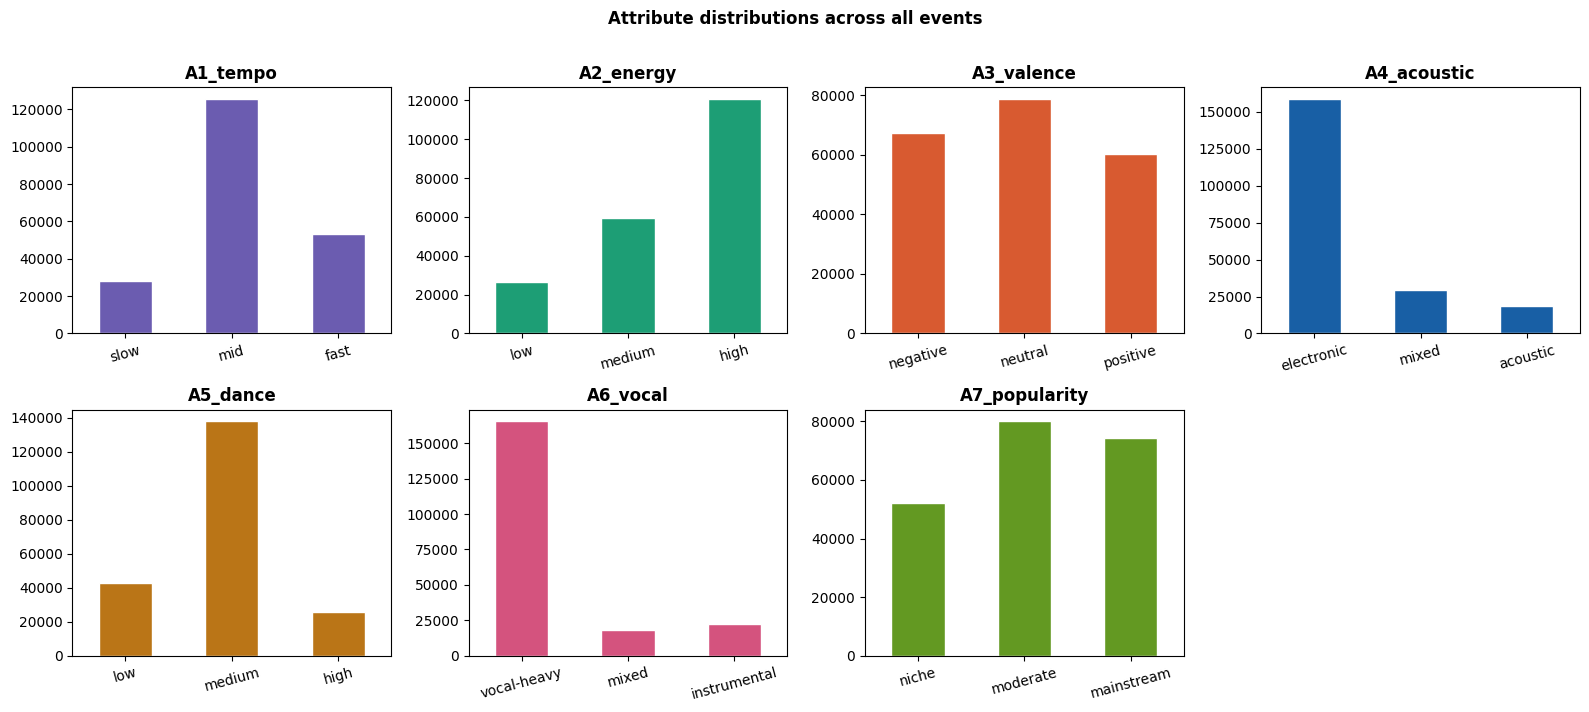


  Chart saved as attribute_distributions.png


In [ ]:
# ── Binning functions ─────────────────────────────────────────────────────────
def bin_tempo(v):
    if v < 90:   return "slow"
    elif v < 140: return "mid"
    else:         return "fast"

def bin_energy(v):
    if v < 0.4:  return "low"
    elif v < 0.7: return "medium"
    else:         return "high"

def bin_valence(v):
    if v < 0.35:  return "negative"
    elif v < 0.65: return "neutral"
    else:          return "positive"

def bin_acousticness(v):
    if v < 0.3:  return "electronic"
    elif v < 0.7: return "mixed"
    else:         return "acoustic"

def bin_danceability(v):
    if v < 0.4:  return "low"
    elif v < 0.7: return "medium"
    else:         return "high"

def bin_vocal(v):
    if v < 0.1:  return "vocal-heavy"
    elif v < 0.5: return "mixed"
    else:         return "instrumental"

def bin_popularity(v):
    if v < 30:  return "niche"
    elif v < 65: return "moderate"
    else:        return "mainstream"

# ── Apply bins ────────────────────────────────────────────────────────────────
events["A1_tempo"]       = events["tempo"].apply(bin_tempo)
events["A2_energy"]      = events["energy"].apply(bin_energy)
events["A3_valence"]     = events["valence"].apply(bin_valence)
events["A4_acoustic"]    = events["acousticness"].apply(bin_acousticness)
events["A5_dance"]       = events["danceability"].apply(bin_danceability)
events["A6_vocal"]       = events["instrumentalness"].apply(bin_vocal)
events["A7_popularity"]  = events["popularity"].apply(bin_popularity)

ATTRS = {
    "A1_tempo":      ["slow", "mid", "fast"],
    "A2_energy":     ["low", "medium", "high"],
    "A3_valence":    ["negative", "neutral", "positive"],
    "A4_acoustic":   ["electronic", "mixed", "acoustic"],
    "A5_dance":      ["low", "medium", "high"],
    "A6_vocal":      ["vocal-heavy", "mixed", "instrumental"],
    "A7_popularity": ["niche", "moderate", "mainstream"],
}

print("✓ Attribute bins applied\n")
print("Sample of final event table:")
cols_show = ["user_id","timestamp","artists","track_name",
             "C1","C2","A1_tempo","A2_energy","A3_valence","A7_popularity"]
print(events[cols_show].head(5).to_string(index=False))

# ── Attribute distribution plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ["#6B5CB0","#1D9E75","#D85A30","#185FA5","#BA7517","#D4537E","#639922"]

for i, (attr, vals) in enumerate(ATTRS.items()):
    counts = events[attr].value_counts().reindex(vals)
    counts.plot(kind="bar", ax=axes[i], color=colors[i], edgecolor="white")
    axes[i].set_title(attr, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

axes[-1].set_visible(False)
plt.suptitle("Attribute distributions across all events", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("attribute_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved as attribute_distributions.png")


## Cell 8 — Save clean event table

Saves the fully annotated event table to `fchs_events.csv`.
This is the input to all subsequent FCHS computations.


In [ ]:
# ── Select final columns ──────────────────────────────────────────────────────
event_cols = (["user_id","timestamp","artists","track_name",
               "C1","C2"] +
              list(ATTRS.keys()) +
              ["energy","valence","tempo","danceability",
               "acousticness","instrumentalness","popularity"])

events_out = events[event_cols].copy()
events_out.to_csv("fchs_events.csv", index=False)

print("✓ Saved fchs_events.csv")
print(f"  Rows    : {len(events_out):,}")
print(f"  Columns : {len(events_out.columns)}")
print(f"  Users   : {events_out['user_id'].nunique()}")
print(f"\nColumn list:")
for c in events_out.columns:
    print(f"  {c}")


✓ Saved fchs_events.csv
  Rows    : 206,471
  Columns : 20
  Users   : 30

Column list:
  user_id
  timestamp
  artists
  track_name
  C1
  C2
  A1_tempo
  A2_energy
  A3_valence
  A4_acoustic
  A5_dance
  A6_vocal
  A7_popularity
  energy
  valence
  tempo
  danceability
  acousticness
  instrumentalness
  popularity


## Cell 9 — Compute fuzzy memberships

**Definition 12 from the paper:**

$$\mu^{u,c}_{A_i}(a) = \frac{n_{u,c}(a)}{N(u,c)}$$

where:
- $N(u,c)$ = total listening events by user $u$ in context $c = (C_1, C_2)$
- $n_{u,c}(a)$ = events with sub-attribute value $a$ in that context

For every `(user, C1, C2)` combination, this computes a full fuzzy
distribution over every sub-attribute value in every attribute space.
Proposition 1 (Partition of Unity) guarantees each attribute's values
sum to 1.0 for every non-empty context.


In [ ]:
MIN_OBS = 5   # minimum observations per context to compute membership

print("Computing fuzzy memberships...")
membership_rows = []

users    = events["user_id"].unique()
C1_vals  = ["early morning","morning","afternoon","evening","night","late night"]
C2_vals  = ["spring","summer","monsoon","winter"]

for user in tqdm(users, desc="  Users"):
    for c1 in C1_vals:
        for c2 in C2_vals:
            subset = events[
                (events["user_id"] == user) &
                (events["C1"] == c1) &
                (events["C2"] == c2)
            ]
            N = len(subset)
            if N < MIN_OBS:
                continue   # skip sparse contexts

            row = {
                "user_id": user,
                "C1_time_slot": c1,
                "C2_season": c2,
                "N_observations": N
            }

            # Compute μ for every attribute and sub-value
            for attr, vals in ATTRS.items():
                counts = subset[attr].value_counts()
                for v in vals:
                    mu = counts.get(v, 0) / N
                    row[f"mu_{attr}_{v}"] = round(mu, 4)

            # Verify Partition of Unity for first attribute
            row["sum_check_A1"] = round(
                sum(row[f"mu_A1_tempo_{v}"] for v in ATTRS["A1_tempo"]), 4
            )
            membership_rows.append(row)

memberships = pd.DataFrame(membership_rows)
print(f"\n✓ Memberships computed")
print(f"  Active (user, context) combinations : {len(memberships):,}")
print(f"  Total possible combinations          : {len(users) * len(C1_vals) * len(C2_vals):,}")
print(f"  Fill rate                            : {len(memberships)/(len(users)*len(C1_vals)*len(C2_vals))*100:.1f}%")

# Verify partition of unity
pu_ok = (memberships["sum_check_A1"] == 1.0).all()
print(f"  Partition of unity (A1 check)        : {'✓ holds for all rows' if pu_ok else '✗ violation detected'}")

print("\nSample membership row (first user, first context):")
sample = memberships.iloc[0]
print(f"  User: {sample['user_id']}")
print(f"  Context: {sample['C1_time_slot']} × {sample['C2_season']}  (N={int(sample['N_observations'])})")
for attr, vals in ATTRS.items():
    vals_str = "  ".join([f"{v}={sample[f'mu_{attr}_{v}']:.3f}" for v in vals])
    print(f"  {attr}: {vals_str}")


Computing fuzzy memberships...


  Users: 100%|██████████| 30/30 [00:51<00:00,  1.72s/it]


✓ Memberships computed
  Active (user, context) combinations : 713
  Total possible combinations          : 720
  Fill rate                            : 99.0%
  Partition of unity (A1 check)        : ✗ violation detected

Sample membership row (first user, first context):
  User: user_000033
  Context: early morning × spring  (N=39)
  A1_tempo: slow=0.256  mid=0.590  fast=0.154
  A2_energy: low=0.000  medium=0.487  high=0.513
  A3_valence: negative=0.795  neutral=0.179  positive=0.026
  A4_acoustic: electronic=0.949  mixed=0.051  acoustic=0.000
  A5_dance: low=0.410  medium=0.590  high=0.000
  A6_vocal: vocal-heavy=0.949  mixed=0.000  instrumental=0.051
  A7_popularity: niche=0.333  moderate=0.385  mainstream=0.282


## Cell 10 — Build dominant profile table

For each `(user, context)` combination, finds the sub-attribute value with
the **highest membership degree** in each attribute dimension — this is the
`arg max` of $\mu^{u,c}_{A_i}$.

The dominant profile tells you: *"When user u listens in context c,
what is their most consistent preference across each attribute?"*


Building dominant profiles...
✓ Dominant profiles built: 713 rows


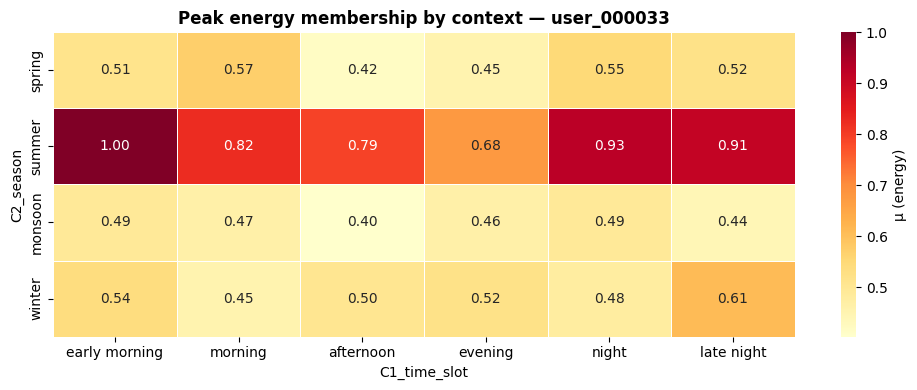

  Heatmap saved as heatmap_energy.png


In [ ]:
print("Building dominant profiles...")
dominant_rows = []

for _, row in memberships.iterrows():
    d = {
        "user_id":      row["user_id"],
        "C1_time_slot": row["C1_time_slot"],
        "C2_season":    row["C2_season"],
        "N":            int(row["N_observations"])
    }
    for attr, vals in ATTRS.items():
        mu_vals   = {v: row[f"mu_{attr}_{v}"] for v in vals}
        best_val  = max(mu_vals, key=mu_vals.get)
        best_mu   = mu_vals[best_val]
        d[f"{attr}_dominant"] = best_val
        d[f"{attr}_mu"]       = round(best_mu, 4)
    dominant_rows.append(d)

dominant = pd.DataFrame(dominant_rows)
print(f"✓ Dominant profiles built: {len(dominant):,} rows")

# ── Heatmap: dominant tempo by context (example) ─────────────────────────────
sample_user = dominant["user_id"].iloc[0]
user_dom    = dominant[dominant["user_id"] == sample_user]

pivot = user_dom.pivot_table(
    index="C2_season", columns="C1_time_slot",
    values="A2_energy_mu", aggfunc="mean"
)
pivot = pivot.reindex(
    index=["spring","summer","monsoon","winter"],
    columns=["early morning","morning","afternoon","evening","night","late night"]
)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "μ (energy)"})
plt.title(f"Peak energy membership by context — {sample_user}", fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_energy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Heatmap saved as heatmap_energy.png")


## Cell 11 — Compute product recommendation scores

**Equation 2 from the paper:**

$$\text{Score}^{u,c}(\mathbf{a}) = \prod_{i=1}^{n} \mu^{u,c}_{A_i}(a_i)$$

The product of all 7 dominant membership values gives one score per
`(user, context)` combination. A high score means the user has
**consistent, concentrated preferences** across all 7 dimensions in
that context — making a confident recommendation possible.


Computing product recommendation scores...
✓ Product scores computed

Score statistics across all (user, context) combinations:
count    713.000000
mean       0.033265
std        0.048088
min        0.006075
25%        0.016883
50%        0.024473
75%        0.037004
max        0.941200


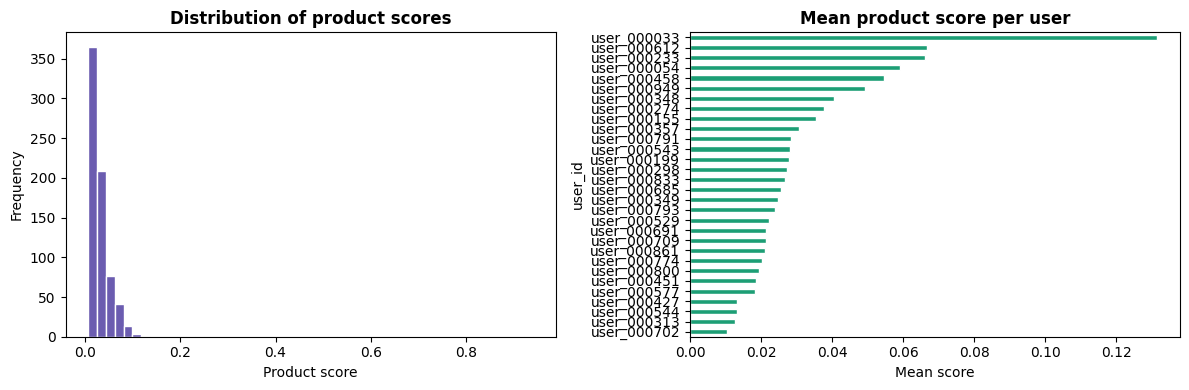

  Chart saved as score_distributions.png


In [ ]:
print("Computing product recommendation scores...")

mu_cols = [f"{attr}_mu" for attr in ATTRS]
dominant["product_score"] = dominant[mu_cols].prod(axis=1).round(8)

# Sort by user then score descending
dominant = dominant.sort_values(
    ["user_id","product_score"], ascending=[True, False]
).reset_index(drop=True)

print("✓ Product scores computed")
print(f"\nScore statistics across all (user, context) combinations:")
print(dominant["product_score"].describe().round(6).to_string())

# ── Score distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dominant["product_score"], bins=50, color="#6B5CB0", edgecolor="white")
axes[0].set_title("Distribution of product scores", fontweight="bold")
axes[0].set_xlabel("Product score")
axes[0].set_ylabel("Frequency")

mean_scores = dominant.groupby("user_id")["product_score"].mean().sort_values()
mean_scores.plot(kind="barh", ax=axes[1], color="#1D9E75", edgecolor="white")
axes[1].set_title("Mean product score per user", fontweight="bold")
axes[1].set_xlabel("Mean score")

plt.tight_layout()
plt.savefig("score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved as score_distributions.png")


## Cell 12 — Generate top-3 recommendations

For each `(user, C1, C2)` context combination, ranks all observed
attribute tuples by product score and returns the top 3.

Each recommendation is a **complete attribute profile** — not just
a genre or a mood, but a full tuple across all 7 dimensions simultaneously.
This granularity is a direct consequence of the FCHS-Set structure.


In [ ]:
print("Generating top-3 recommendations...")

# ── Join dominant profile back to actual observed attribute tuples ─────────────
# Group events and score each unique attribute tuple per (user, context)
attr_cols = list(ATTRS.keys())
grouped   = (events
    .groupby(["user_id","C1","C2"] + attr_cols)
    .size()
    .reset_index(name="play_count"))

# Merge membership values for each attribute value in the tuple
def score_tuple(row, membership_df):
    matches = membership_df[
        (membership_df["user_id"]      == row["user_id"]) &
        (membership_df["C1_time_slot"] == row["C1"]) &
        (membership_df["C2_season"]    == row["C2"])
    ]
    if matches.empty:
        return np.nan
    m = matches.iloc[0]
    score = 1.0
    for attr in ATTRS:
        val = row[attr]
        mu  = m.get(f"mu_{attr}_{val}", 0)
        score *= mu
    return round(score, 8)

tqdm.pandas(desc="  Scoring tuples")
grouped["product_score"] = grouped.progress_apply(
    lambda r: score_tuple(r, memberships), axis=1
)
grouped = grouped.dropna(subset=["product_score"])

# ── Top-3 per (user, context) ─────────────────────────────────────────────────
recs = (grouped
    .sort_values("product_score", ascending=False)
    .groupby(["user_id","C1","C2"])
    .head(3)
    .copy()
)
recs["rank"] = (recs
    .groupby(["user_id","C1","C2"])["product_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)
recs = recs.sort_values(["user_id","C1","C2","rank"]).reset_index(drop=True)

print(f"\n✓ Recommendations generated")
print(f"  Total recommendation rows : {len(recs):,}")
print(f"  Active (user, context) cells : {recs.groupby(['user_id','C1','C2']).ngroups:,}")

print("\nSample — top-3 for first user, first context:")
sample = recs[recs["user_id"] == recs["user_id"].iloc[0]].head(9)
display_cols = ["C1","C2","rank","A1_tempo","A2_energy","A3_valence",
                "A4_acoustic","A5_dance","A6_vocal","A7_popularity","product_score"]
print(sample[display_cols].to_string(index=False))


Generating top-3 recommendations...


  Scoring tuples: 100%|██████████| 60427/60427 [01:06<00:00, 909.35it/s] 



✓ Recommendations generated
  Total recommendation rows : 2,138
  Active (user, context) cells : 713

Sample — top-3 for first user, first context:
       C1      C2  rank A1_tempo A2_energy A3_valence A4_acoustic A5_dance    A6_vocal A7_popularity  product_score
afternoon monsoon     1      mid    medium   negative  electronic   medium vocal-heavy         niche       0.014063
afternoon monsoon     2      mid    medium   negative       mixed   medium vocal-heavy         niche       0.011291
afternoon monsoon     3      mid      high    neutral       mixed   medium vocal-heavy         niche       0.009766
afternoon  spring     1      mid      high   negative  electronic   medium vocal-heavy      moderate       0.012374
afternoon  spring     2     slow    medium   negative  electronic   medium vocal-heavy      moderate       0.009846
afternoon  spring     3      mid    medium   negative  electronic   medium vocal-heavy      moderate       0.009282
afternoon  summer     1     slow      h

## Cell 13 — Summary statistics for the paper

Generates the key numbers you need to report in Section 5 of the paper:
dataset statistics, active context combinations, score distributions.


  FCHS-SET SUMMARY STATISTICS
  Total listening events         : 206,471
  Users (|U|)                    : 30
  Unique tracks                  : 4,990
  Unique artists                 : 1,768
  Date range                     : 2005-02-14 → 2009-06-19

  Context dimensions (m)         : 2
  C1 levels (time slot)          : 6
  C2 levels (season)             : 4
  Total context combinations     : 24

  Attribute dimensions (n)       : 7
  Total sub-attribute values     : 21

  Active (user×context) cells    : 713
  Max possible cells             : 720
  Fill rate                      : 99.0%

  Recommendation rows            : 2,138
  Mean product score             : 0.025858
  Max product score              : 0.941200
  Min product score              : 0.002458


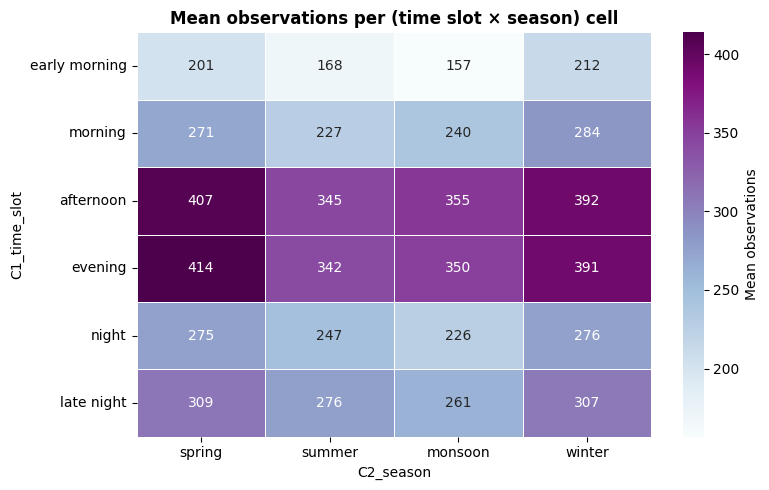

  Chart saved as context_heatmap.png


In [ ]:
print("=" * 60)
print("  FCHS-SET SUMMARY STATISTICS")
print("=" * 60)
print(f"  Total listening events         : {len(events):,}")
print(f"  Users (|U|)                    : {events['user_id'].nunique()}")
print(f"  Unique tracks                  : {events['track_name'].nunique():,}")
print(f"  Unique artists                 : {events['artists'].nunique():,}")
print(f"  Date range                     : {events['timestamp'].min().date()} → {events['timestamp'].max().date()}")
print()
print(f"  Context dimensions (m)         : 2")
print(f"  C1 levels (time slot)          : 6")
print(f"  C2 levels (season)             : 4")
print(f"  Total context combinations     : 24")
print()
print(f"  Attribute dimensions (n)       : 7")
total_subattrs = sum(len(v) for v in ATTRS.values())
print(f"  Total sub-attribute values     : {total_subattrs}")
print()
print(f"  Active (user×context) cells    : {len(memberships):,}")
max_possible = events['user_id'].nunique() * 24
print(f"  Max possible cells             : {max_possible:,}")
print(f"  Fill rate                      : {len(memberships)/max_possible*100:.1f}%")
print()
print(f"  Recommendation rows            : {len(recs):,}")
print(f"  Mean product score             : {recs['product_score'].mean():.6f}")
print(f"  Max product score              : {recs['product_score'].max():.6f}")
print(f"  Min product score              : {recs['product_score'].min():.6f}")
print("=" * 60)

# ── Mean score heatmap across all users ──────────────────────────────────────
mean_scores = (memberships
    .groupby(["C1_time_slot","C2_season"])["N_observations"]
    .mean()
    .unstack()
    .reindex(
        index=["early morning","morning","afternoon","evening","night","late night"],
        columns=["spring","summer","monsoon","winter"]
    )
)
plt.figure(figsize=(8, 5))
sns.heatmap(mean_scores, annot=True, fmt=".0f", cmap="BuPu",
            linewidths=0.5, cbar_kws={"label": "Mean observations"})
plt.title("Mean observations per (time slot × season) cell", fontweight="bold")
plt.tight_layout()
plt.savefig("context_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved as context_heatmap.png")


## Cell 14 — Export all results to CSV

Saves three output files:
- `fchs_events.csv` — clean annotated event table
- `fchs_memberships.csv` — fuzzy membership values per (user, context)
- `fchs_recommendations.csv` — top-3 recommendations per (user, context)
- `fchs_dominant_profile.csv` — dominant attribute profile per (user, context)


In [ ]:
# ── Save memberships ──────────────────────────────────────────────────────────
memberships.to_csv("fchs_memberships.csv", index=False)
print(f"✓ Saved fchs_memberships.csv  ({len(memberships):,} rows)")

# ── Save dominant profile ─────────────────────────────────────────────────────
dominant.to_csv("fchs_dominant_profile.csv", index=False)
print(f"✓ Saved fchs_dominant_profile.csv  ({len(dominant):,} rows)")

# ── Save recommendations ──────────────────────────────────────────────────────
recs.to_csv("fchs_recommendations.csv", index=False)
print(f"✓ Saved fchs_recommendations.csv  ({len(recs):,} rows)")

# ── Download in Colab ─────────────────────────────────────────────────────────
try:
    from google.colab import files
    for fname in ["fchs_events.csv", "fchs_memberships.csv",
                  "fchs_dominant_profile.csv", "fchs_recommendations.csv"]:
        files.download(fname)
    print("\n✓ Files downloading to your computer...")
except ImportError:
    print("\n  (Running locally — files saved in current directory)")

print("\nPipeline complete.")


✓ Saved fchs_memberships.csv  (713 rows)
✓ Saved fchs_dominant_profile.csv  (713 rows)
✓ Saved fchs_recommendations.csv  (2,138 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Files downloading to your computer...

Pipeline complete.
